In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_columns", 200)
df = pd.read_csv("data/candidate_scored_final.csv", encoding='utf-8')

score_cols = [
    "채널력점수",
    "성장성점수",
    "팬밀도점수",
    "라이브친화점수",
    "실전성점수"
]

df[score_cols].head()

,채널력점수,성장성점수,팬밀도점수,라이브친화점수,실전성점수
0,0.832100,0.619485,0.908747,0.915690,0.99272
1,0.672003,0.789153,0.958963,0.522037,0.99272
2,0.510718,0.779387,0.852592,0.857111,0.99272
3,0.886690,0.604305,0.703024,0.846040,0.99272
4,0.537959,0.752245,0.800756,0.850653,1.00000


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 상관관계 검증 함수
# ============================================================

def validate_score_correlations(
    df,
    score_cols=None,
    method="spearman",
    threshold=0.8,
    figsize=(8, 6),
    show_plot=True
):
    """
    스타시드 점수 구성 지표 간 상관관계를 검증하는 함수

    Parameters
    ----------
    df : pd.DataFrame
        분석 대상 데이터프레임

    score_cols : list, optional
        상관관계를 확인할 점수 컬럼 리스트
        None이면 기본 스타시드 점수 컬럼명을 사용

    method : str, default="spearman"
        상관계수 계산 방식
        - "spearman": 순위 기반 상관관계
        - "pearson": 선형 상관관계
        - "kendall": 순위 기반이나 표본이 작을 때 사용 가능

    threshold : float, default=0.8
        강한 상관관계로 판단할 기준값

    figsize : tuple, default=(8, 6)
        히트맵 크기

    show_plot : bool, default=True
        True이면 상관관계 히트맵 출력

    Returns
    -------
    result : dict
        {
            "corr_matrix": 상관계수 행렬,
            "high_corr_pairs": 기준값 이상으로 상관이 높은 지표쌍,
            "summary": 요약 문장
        }
    """

    # ------------------------------------------------------------
    # 기본 점수 컬럼 설정
    # ------------------------------------------------------------
    if score_cols is None:
        score_cols = [
            "채널력점수",
            "성장성점수",
            "팬밀도점수",
            "라이브친화점수",
            "실전성점수"
        ]

    # ------------------------------------------------------------
    # 컬럼 존재 여부 확인
    # ------------------------------------------------------------
    missing_cols = [col for col in score_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(
            f"다음 컬럼이 df에 존재하지 않습니다: {missing_cols}\n"
            f"현재 df 컬럼 예시: {list(df.columns[:30])}"
        )

    # ------------------------------------------------------------
    # 숫자형 변환
    # ------------------------------------------------------------
    score_df = df[score_cols].copy()

    for col in score_cols:
        score_df[col] = pd.to_numeric(score_df[col], errors="coerce")

    # ------------------------------------------------------------
    # 결측치 제거
    # ------------------------------------------------------------
    before_rows = len(score_df)
    score_df = score_df.dropna()
    after_rows = len(score_df)

    if after_rows == 0:
        raise ValueError("상관관계를 계산할 수 있는 유효한 행이 없습니다. 점수 컬럼의 결측치/자료형을 확인하세요.")

    # ------------------------------------------------------------
    # 상관계수 행렬 계산
    # ------------------------------------------------------------
    corr_matrix = score_df.corr(method=method)

    # ------------------------------------------------------------
    # 강한 상관관계 지표쌍 추출
    # ------------------------------------------------------------
    high_corr_pairs = []

    cols = corr_matrix.columns

    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            col1 = cols[i]
            col2 = cols[j]
            corr_value = corr_matrix.loc[col1, col2]

            if abs(corr_value) >= threshold:
                high_corr_pairs.append({
                    "지표1": col1,
                    "지표2": col2,
                    "상관계수": round(corr_value, 4),
                    "판정": "강한 양의 상관" if corr_value > 0 else "강한 음의 상관"
                })

    high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

    # ------------------------------------------------------------
    # 히트맵 시각화
    # ------------------------------------------------------------
    if show_plot:
        plt.figure(figsize=figsize)

        im = plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

        plt.colorbar(im, fraction=0.046, pad=0.04)
        plt.xticks(range(len(cols)), cols, rotation=45, ha="right")
        plt.yticks(range(len(cols)), cols)

        for i in range(len(cols)):
            for j in range(len(cols)):
                value = corr_matrix.iloc[i, j]
                plt.text(
                    j,
                    i,
                    f"{value:.2f}",
                    ha="center",
                    va="center",
                    color="black" if abs(value) < 0.6 else "white",
                    fontsize=11
                )

        plt.title(f"스타시드 하위 지표 간 상관관계 검증 ({method})", fontsize=14, pad=15)
        plt.tight_layout()
        plt.show()

    # ------------------------------------------------------------
    # 요약 문장 생성
    # ------------------------------------------------------------
    if len(high_corr_pairs) == 0:
        summary = (
            f"{method} 기준으로 절대값 {threshold} 이상의 강한 상관관계는 발견되지 않았습니다. "
            "따라서 특정 하위 지표가 다른 지표와 과도하게 중복 반영될 가능성은 낮아 보입니다."
        )
    else:
        summary = (
            f"{method} 기준으로 절대값 {threshold} 이상의 강한 상관관계가 "
            f"{len(high_corr_pairs)}건 발견되었습니다. "
            "해당 지표쌍은 점수 산식에서 중복 반영 가능성이 있으므로 가중치 조정 또는 지표 재정의 검토가 필요합니다."
        )

    # ------------------------------------------------------------
    # 결과 반환
    # ------------------------------------------------------------
    result = {
        "corr_matrix": corr_matrix,
        "high_corr_pairs": high_corr_pairs_df,
        "summary": summary,
        "used_rows": after_rows,
        "dropped_rows": before_rows - after_rows
    }

    return result

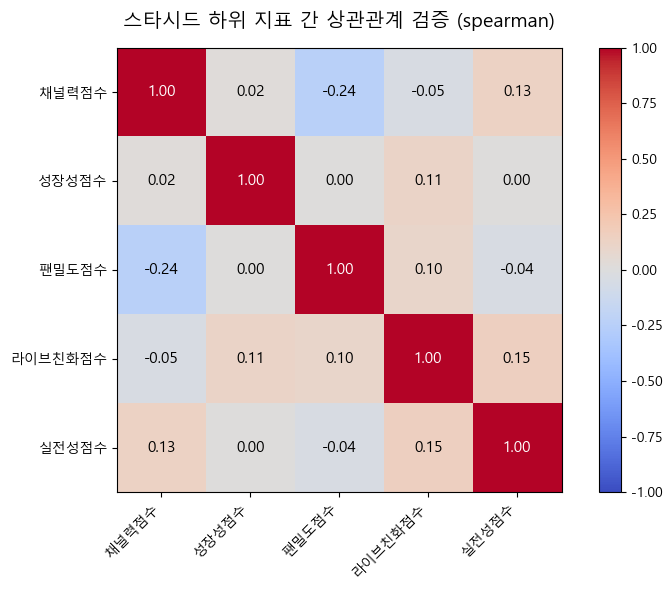

,채널력점수,성장성점수,팬밀도점수,라이브친화점수,실전성점수
채널력점수,1.000000,0.020402,-0.242003,-0.045181,0.127576
성장성점수,0.020402,1.000000,0.002690,0.112308,0.002587
팬밀도점수,-0.242003,0.002690,1.000000,0.097530,-0.039265
라이브친화점수,-0.045181,0.112308,0.097530,1.000000,0.152915
실전성점수,0.127576,0.002587,-0.039265,0.152915,1.000000


In [10]:
score_cols = [
    "채널력점수",
    "성장성점수",
    "팬밀도점수",
    "라이브친화점수",
    "실전성점수"
]

corr_result = validate_score_correlations(
    df=df,
    score_cols=score_cols,
    method="spearman",
    threshold=0.8,
    figsize=(10, 6),
    show_plot=True
)

corr_result["corr_matrix"]

In [4]:
def make_correlation_report_table(corr_result):
    """
    상관관계 검증 결과를 PPT/보고서용 테이블 형태로 정리
    """

    high_corr_pairs = corr_result["high_corr_pairs"]

    if high_corr_pairs.empty:
        report_df = pd.DataFrame({
            "검증 항목": ["하위 지표 간 상관관계"],
            "검증 방법": ["Spearman 상관계수"],
            "검증 결과": ["강한 상관관계 없음"],
            "해석": ["특정 지표가 과도하게 중복 반영될 가능성은 낮음"]
        })
    else:
        report_df = high_corr_pairs.copy()
        report_df["검증 항목"] = "하위 지표 간 상관관계"
        report_df["검증 방법"] = "Spearman 상관계수"
        report_df["해석"] = report_df["지표1"] + "와 " + report_df["지표2"] + " 간 중복 반영 가능성 검토 필요"

        report_df = report_df[
            ["검증 항목", "검증 방법", "지표1", "지표2", "상관계수", "판정", "해석"]
        ]

    return report_df


corr_report_df = make_correlation_report_table(corr_result)
corr_report_df

,검증 항목,검증 방법,검증 결과,해석
0,하위 지표 간 상관관계,Spearman 상관계수,강한 상관관계 없음,특정 지표가 과도하게 중복 반영될 가능성은 낮음


In [11]:
import numpy as np
from scipy.stats import spearmanr, pearsonr
from itertools import combinations

# ============================================================
# 스타시드 하위 지표 간 p-value + effect size 계산 함수
# ============================================================

def correlation_significance_test(
    df,
    score_cols=None,
    method="spearman",
    alpha=0.05,
    adjust_p=True
):
    """
    스타시드 하위 점수 변수 간 상관계수, p-value, effect size를 계산하는 함수

    Parameters
    ----------
    df : pd.DataFrame
        분석 대상 데이터프레임

    score_cols : list
        분석할 점수 컬럼 리스트

    method : str
        "spearman" 또는 "pearson"

    alpha : float
        유의수준. 기본값 0.05

    adjust_p : bool
        True이면 Bonferroni 보정 p-value도 계산

    Returns
    -------
    result_df : pd.DataFrame
        변수쌍별 상관계수, p-value, effect size 결과
    """

    # ------------------------------------------------------------
    # 기본 컬럼 설정
    # ------------------------------------------------------------
    if score_cols is None:
        score_cols = [
            "채널력점수",
            "성장성점수",
            "팬밀도점수",
            "라이브친화점수",
            "실전성점수"
        ]

    # ------------------------------------------------------------
    # 컬럼 존재 여부 확인
    # ------------------------------------------------------------
    missing_cols = [col for col in score_cols if col not in df.columns]

    if missing_cols:
        raise ValueError(
            f"다음 컬럼이 df에 없습니다: {missing_cols}\n"
            f"현재 df 컬럼 예시: {list(df.columns[:30])}"
        )

    # ------------------------------------------------------------
    # 숫자형 변환
    # ------------------------------------------------------------
    data = df[score_cols].copy()

    for col in score_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    # ------------------------------------------------------------
    # 변수쌍별 상관계수, p-value 계산
    # ------------------------------------------------------------
    results = []

    for col1, col2 in combinations(score_cols, 2):
        pair_df = data[[col1, col2]].dropna()

        n = len(pair_df)

        if n < 3:
            corr = np.nan
            p_value = np.nan
        else:
            if method == "spearman":
                corr, p_value = spearmanr(pair_df[col1], pair_df[col2])
            elif method == "pearson":
                corr, p_value = pearsonr(pair_df[col1], pair_df[col2])
            else:
                raise ValueError("method는 'spearman' 또는 'pearson'만 가능합니다.")

        abs_corr = abs(corr) if pd.notna(corr) else np.nan
        effect_size_r2 = corr ** 2 if pd.notna(corr) else np.nan

        # --------------------------------------------------------
        # 효과크기 해석 기준
        # Cohen 기준을 상관계수에 적용
        # |r| < 0.1: 거의 없음
        # 0.1 이상: 약함
        # 0.3 이상: 보통
        # 0.5 이상: 큼
        # --------------------------------------------------------
        if pd.isna(abs_corr):
            effect_label = "계산 불가"
        elif abs_corr < 0.1:
            effect_label = "거의 없음"
        elif abs_corr < 0.3:
            effect_label = "약한 효과"
        elif abs_corr < 0.5:
            effect_label = "보통 효과"
        else:
            effect_label = "큰 효과"

        results.append({
            "변수1": col1,
            "변수2": col2,
            "표본수": n,
            "검정방법": method,
            "상관계수": corr,
            "p_value": p_value,
            "effect_size_abs_r": abs_corr,
            "effect_size_r2": effect_size_r2,
            "효과크기해석": effect_label
        })

    result_df = pd.DataFrame(results)

    # ------------------------------------------------------------
    # Bonferroni 보정 p-value 계산
    # 여러 변수쌍을 동시에 검정하므로 보수적으로 보정
    # ------------------------------------------------------------
    if adjust_p:
        m = len(result_df)
        result_df["p_value_bonferroni"] = (result_df["p_value"] * m).clip(upper=1)
        result_df["유의성"] = np.where(
            result_df["p_value_bonferroni"] < alpha,
            "유의함",
            "유의하지 않음"
        )
    else:
        result_df["유의성"] = np.where(
            result_df["p_value"] < alpha,
            "유의함",
            "유의하지 않음"
        )

    # ------------------------------------------------------------
    # 보기 좋게 반올림
    # ------------------------------------------------------------
    round_cols = [
        "상관계수",
        "p_value",
        "effect_size_abs_r",
        "effect_size_r2"
    ]

    if adjust_p:
        round_cols.append("p_value_bonferroni")

    for col in round_cols:
        result_df[col] = result_df[col].round(6)

    return result_df


# ============================================================
# 실행 예시
# ============================================================

score_cols = [
    "채널력점수",
    "성장성점수",
    "팬밀도점수",
    "라이브친화점수",
    "실전성점수"
]

corr_test_result = correlation_significance_test(
    df=df,
    score_cols=score_cols,
    method="spearman",
    alpha=0.05,
    adjust_p=True
)

corr_test_result

,변수1,변수2,표본수,검정방법,상관계수,p_value,effect_size_abs_r,effect_size_r2,효과크기해석,p_value_bonferroni,유의성
0,채널력점수,성장성점수,1852,spearman,0.020402,0.380226,0.020402,0.000416,거의 없음,1.000000,유의하지 않음
1,채널력점수,팬밀도점수,1852,spearman,-0.242003,0.000000,0.242003,0.058566,약한 효과,0.000000,유의함
2,채널력점수,라이브친화점수,1852,spearman,-0.045181,0.051891,0.045181,0.002041,거의 없음,0.518913,유의하지 않음
3,채널력점수,실전성점수,1852,spearman,0.127576,0.000000,0.127576,0.016276,약한 효과,0.000000,유의함
4,성장성점수,팬밀도점수,1852,spearman,0.002690,0.907897,0.002690,0.000007,거의 없음,1.000000,유의하지 않음
5,성장성점수,라이브친화점수,1852,spearman,0.112308,0.000001,0.112308,0.012613,약한 효과,0.000013,유의함
6,성장성점수,실전성점수,1852,spearman,0.002587,0.911424,0.002587,0.000007,거의 없음,1.000000,유의하지 않음
7,팬밀도점수,라이브친화점수,1852,spearman,0.097530,0.000026,0.097530,0.009512,거의 없음,0.000262,유의함
8,팬밀도점수,실전성점수,1852,spearman,-0.039265,0.091165,0.039265,0.001542,거의 없음,0.911652,유의하지 않음
9,라이브친화점수,실전성점수,1852,spearman,0.152915,0.000000,0.152915,0.023383,약한 효과,0.000000,유의함


In [13]:
ppt_corr_result = corr_test_result[
    [
        "변수1",
        "변수2",
        "상관계수",
        "p_value",
        "effect_size_abs_r",
        "effect_size_r2",
        "효과크기해석",
        "유의성"
    ]
].copy()

ppt_corr_result

,변수1,변수2,상관계수,p_value,effect_size_abs_r,effect_size_r2,효과크기해석,유의성
0,채널력점수,성장성점수,0.020402,0.380226,0.020402,0.000416,거의 없음,유의하지 않음
1,채널력점수,팬밀도점수,-0.242003,0.000000,0.242003,0.058566,약한 효과,유의함
2,채널력점수,라이브친화점수,-0.045181,0.051891,0.045181,0.002041,거의 없음,유의하지 않음
3,채널력점수,실전성점수,0.127576,0.000000,0.127576,0.016276,약한 효과,유의함
4,성장성점수,팬밀도점수,0.002690,0.907897,0.002690,0.000007,거의 없음,유의하지 않음
5,성장성점수,라이브친화점수,0.112308,0.000001,0.112308,0.012613,약한 효과,유의함
6,성장성점수,실전성점수,0.002587,0.911424,0.002587,0.000007,거의 없음,유의하지 않음
7,팬밀도점수,라이브친화점수,0.097530,0.000026,0.097530,0.009512,거의 없음,유의함
8,팬밀도점수,실전성점수,-0.039265,0.091165,0.039265,0.001542,거의 없음,유의하지 않음
9,라이브친화점수,실전성점수,0.152915,0.000000,0.152915,0.023383,약한 효과,유의함


스타시드 핵심 지표 간 Spearman 상관계수와 p-value를 계산하고, 상관계수 절대값을 effect size로 해석하였다.  
표본수가 충분히 큰 데이터에서는 작은 상관도 통계적으로 유의할 수 있으므로, p-value뿐 아니라 effect size를 함께 검토하였다.

In [14]:
ppt_corr_simple = corr_test_result.rename(columns={
    "변수1": "지표 A",
    "변수2": "지표 B",
    "상관계수": "상관 방향·크기",
    "p_value": "통계적 유의확률",
    "effect_size_abs_r": "관계 강도",
    "효과크기해석": "관계 강도 해석",
    "유의성": "통계적 유의 여부"
})[
    [
        "지표 A",
        "지표 B",
        "상관 방향·크기",
        "통계적 유의확률",
        "관계 강도",
        "관계 강도 해석",
        "통계적 유의 여부"
    ]
]

ppt_corr_simple

,지표 A,지표 B,상관 방향·크기,통계적 유의확률,관계 강도,관계 강도 해석,통계적 유의 여부
0,채널력점수,성장성점수,0.020402,0.380226,0.020402,거의 없음,유의하지 않음
1,채널력점수,팬밀도점수,-0.242003,0.000000,0.242003,약한 효과,유의함
2,채널력점수,라이브친화점수,-0.045181,0.051891,0.045181,거의 없음,유의하지 않음
3,채널력점수,실전성점수,0.127576,0.000000,0.127576,약한 효과,유의함
4,성장성점수,팬밀도점수,0.002690,0.907897,0.002690,거의 없음,유의하지 않음
5,성장성점수,라이브친화점수,0.112308,0.000001,0.112308,약한 효과,유의함
6,성장성점수,실전성점수,0.002587,0.911424,0.002587,거의 없음,유의하지 않음
7,팬밀도점수,라이브친화점수,0.097530,0.000026,0.097530,거의 없음,유의함
8,팬밀도점수,실전성점수,-0.039265,0.091165,0.039265,거의 없음,유의하지 않음
9,라이브친화점수,실전성점수,0.152915,0.000000,0.152915,약한 효과,유의함


In [15]:
ppt_corr_simple = corr_test_result.rename(columns={
    "변수1": "지표 A",
    "변수2": "지표 B",
    "상관계수": "상관 방향·크기",
    "p_value": "통계적 유의확률",
    "effect_size_abs_r": "관계 강도",
    "효과크기해석": "관계 강도 해석",
    "유의성": "통계적 유의 여부"
})[
    [
        "지표 A",
        "지표 B",
        "상관 방향·크기",
        "통계적 유의확률",
        "관계 강도",
        "관계 강도 해석",
        "통계적 유의 여부"
    ]
].copy()

ppt_corr_simple["상관 방향·크기"] = ppt_corr_simple["상관 방향·크기"].round(3)
ppt_corr_simple["통계적 유의확률"] = ppt_corr_simple["통계적 유의확률"].round(4)
ppt_corr_simple["관계 강도"] = ppt_corr_simple["관계 강도"].round(3)

ppt_corr_simple

,지표 A,지표 B,상관 방향·크기,통계적 유의확률,관계 강도,관계 강도 해석,통계적 유의 여부
0,채널력점수,성장성점수,0.020,0.3802,0.020,거의 없음,유의하지 않음
1,채널력점수,팬밀도점수,-0.242,0.0000,0.242,약한 효과,유의함
2,채널력점수,라이브친화점수,-0.045,0.0519,0.045,거의 없음,유의하지 않음
3,채널력점수,실전성점수,0.128,0.0000,0.128,약한 효과,유의함
4,성장성점수,팬밀도점수,0.003,0.9079,0.003,거의 없음,유의하지 않음
5,성장성점수,라이브친화점수,0.112,0.0000,0.112,약한 효과,유의함
6,성장성점수,실전성점수,0.003,0.9114,0.003,거의 없음,유의하지 않음
7,팬밀도점수,라이브친화점수,0.098,0.0000,0.098,거의 없음,유의함
8,팬밀도점수,실전성점수,-0.039,0.0912,0.039,거의 없음,유의하지 않음
9,라이브친화점수,실전성점수,0.153,0.0000,0.153,약한 효과,유의함


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. 상관관계 검증 결과 시각화 함수
# ============================================================

def plot_correlation_effect_size(
    result_df,
    var1_col="변수1",
    var2_col="변수2",
    corr_col="상관계수",
    p_col="p_value",
    effect_col="effect_size_abs_r",
    effect_label_col="효과크기해석",
    sig_col="유의성",
    title="스타시드 하위 지표 간 관계 강도",
    figsize=(10, 6),
    save_path=None
):
    """
    스타시드 하위 지표 간 상관관계 검증 결과를
    PPT용 막대그래프로 시각화하는 함수

    Parameters
    ----------
    result_df : pd.DataFrame
        correlation_significance_test 함수 결과 데이터프레임

    var1_col, var2_col : str
        비교 지표 컬럼명

    corr_col : str
        상관계수 컬럼명

    p_col : str
        p-value 컬럼명

    effect_col : str
        effect size 컬럼명. 보통 effect_size_abs_r 사용

    effect_label_col : str
        효과크기해석 컬럼명

    sig_col : str
        유의성 컬럼명

    title : str
        그래프 제목

    figsize : tuple
        그래프 크기

    save_path : str or None
        저장 경로. 예: "starseed_corr_effect_size.png"
    """

    df_plot = result_df.copy()

    # ------------------------------------------------------------
    # 컬럼명 자동 대응
    # ------------------------------------------------------------
    rename_map = {
        "지표 A": "변수1",
        "지표 B": "변수2",
        "상관 방향·크기": "상관계수",
        "통계적 유의확률": "p_value",
        "관계 강도": "effect_size_abs_r",
        "관계 강도 해석": "효과크기해석",
        "통계적 유의 여부": "유의성"
    }

    df_plot = df_plot.rename(columns=rename_map)

    var1_col = "변수1"
    var2_col = "변수2"
    corr_col = "상관계수"
    p_col = "p_value"
    effect_col = "effect_size_abs_r"
    effect_label_col = "효과크기해석"
    sig_col = "유의성"

    # ------------------------------------------------------------
    # 표시용 지표쌍 라벨 생성
    # ------------------------------------------------------------
    df_plot["지표쌍"] = df_plot[var1_col] + " - " + df_plot[var2_col]

    # ------------------------------------------------------------
    # 관계 강도 기준 정렬
    # ------------------------------------------------------------
    df_plot = df_plot.sort_values(effect_col, ascending=True)

    # ------------------------------------------------------------
    # 유의성 여부에 따른 색상 구분용 값 생성
    # matplotlib 기본 색상 사용
    # ------------------------------------------------------------
    colors = np.where(df_plot[sig_col].eq("유의함"), "tab:blue", "tab:gray")

    # ------------------------------------------------------------
    # 그래프 생성
    # ------------------------------------------------------------
    plt.figure(figsize=figsize)

    bars = plt.barh(
        df_plot["지표쌍"],
        df_plot[effect_col],
        color=colors
    )

    # ------------------------------------------------------------
    # 값 라벨 표시
    # ------------------------------------------------------------
    for bar, corr, pval, label in zip(
        bars,
        df_plot[corr_col],
        df_plot[p_col],
        df_plot[effect_label_col]
    ):
        width = bar.get_width()

        plt.text(
            width + 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"r={corr:.3f}, p={pval:.4f}, {label}",
            va="center",
            fontsize=9
        )

    # ------------------------------------------------------------
    # 효과크기 기준선
    # ------------------------------------------------------------
    plt.axvline(0.1, linestyle="--", linewidth=1, label="약한 효과 기준 |r|=0.1")
    plt.axvline(0.3, linestyle="--", linewidth=1, label="보통 효과 기준 |r|=0.3")

    plt.title(title, fontsize=14, pad=15)
    plt.legend(loc="lower right")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

    return df_plot

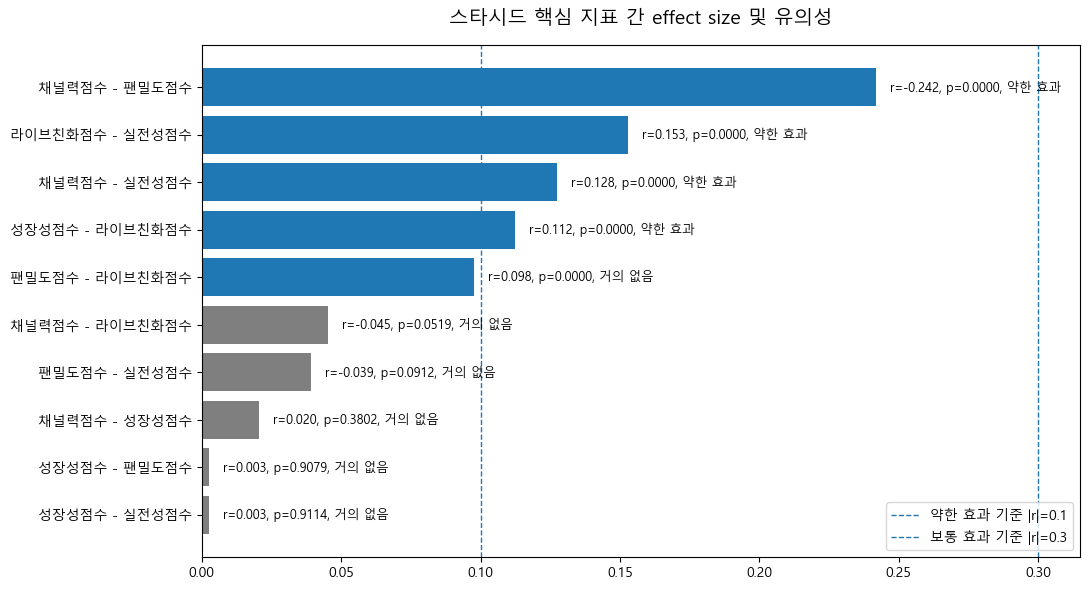

In [20]:
plot_df = plot_correlation_effect_size(
    corr_test_result,
    title="스타시드 핵심 지표 간 effect size 및 유의성",
    figsize=(11, 6),
    save_path="starseed_corr_effect_size.png"
)

In [25]:
df2 = df[(df['액션버킷'] == '즉시검토')&(df['대표상위세그먼트'].notna())]

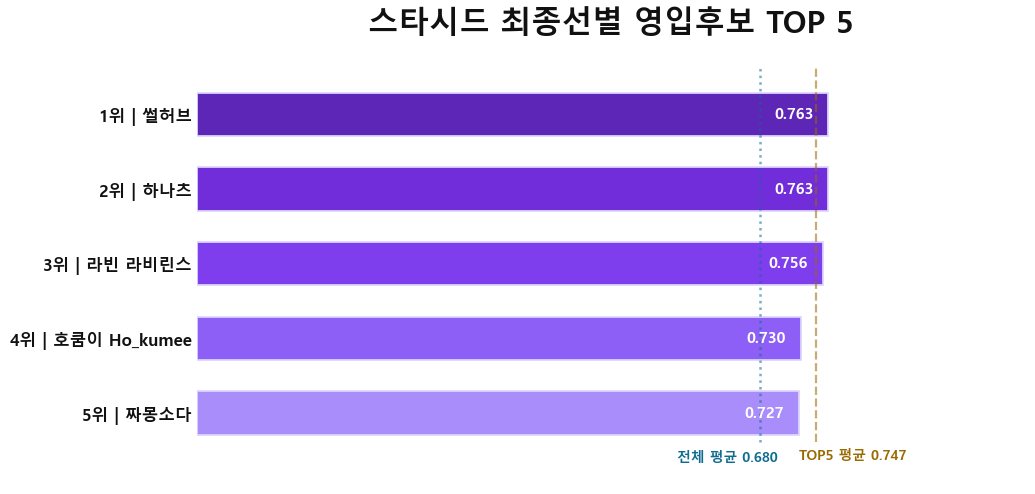

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform

# ============================================================
# 스타시드 최종선별 영입후보 TOP 5 막대그래프
# - df2 현재 정렬 순서 기준
# - 표시순위 1~5위 재매핑
# - 1위 진한 보라색 → 5위 연한 보라색
# - TOP5 평균선 + 전체 평균선
# - x축 숫자/눈금/라벨 제거
# ============================================================

# ------------------------------------------------------------
# 0. 한글 폰트 설정
# ------------------------------------------------------------
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 1. 데이터 준비
# ------------------------------------------------------------
df_plot = df2.copy()

# 최종점수 숫자형 변환
df_plot["최종점수"] = pd.to_numeric(df_plot["최종점수"], errors="coerce")

# df2의 현재 정렬 순서를 그대로 유지한 채 표시순위 재부여
df_plot = df_plot.reset_index(drop=True)
df_plot["표시순위"] = df_plot.index + 1

# 현재 df2 기준 TOP 5 추출
top5 = (
    df_plot
    .dropna(subset=["최종점수"])
    .head(5)
    .copy()
)

# 표시용 채널명
top5["표시채널명"] = (
    top5["표시순위"].astype(int).astype(str)
    + "위 | "
    + top5["채널명"].astype(str)
)

# barh에서는 아래에서 위로 그려지므로 5위 → 1위 순서로 뒤집기
top5_plot = top5.iloc[::-1].copy()

# ------------------------------------------------------------
# 2. 색상 설정
# ------------------------------------------------------------

# 1위가 가장 진하고, 5위가 가장 연한 보라색
rank_color_map = {
    1: "#5B21B6",  # 가장 진한 보라
    2: "#6D28D9",
    3: "#7C3AED",
    4: "#8B5CF6",
    5: "#A78BFA"   # 가장 연한 보라
}

bar_colors = top5_plot["표시순위"].map(rank_color_map).tolist()

# 기준선과 텍스트는 너무 밝지 않게 어두운 계열로 조정
top5_mean_color = "#9A6A00"     # 어두운 골드/브라운
overall_mean_color = "#0F6B8F"  # 어두운 청록/블루

bar_edge_color = "#DDD6FE"
text_color = "#111111"
sub_text_color = "#333333"
grid_color = "#E5E7EB"

# ------------------------------------------------------------
# 3. 그래프 생성
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5.8), facecolor="white")
ax.set_facecolor("white")

y_pos = np.arange(len(top5_plot))

bars = ax.barh(
    y_pos,
    top5_plot["최종점수"],
    height=0.58,
    color=bar_colors,
    edgecolor=bar_edge_color,
    linewidth=1.3,
    alpha=0.98
)

# ------------------------------------------------------------
# 4. 막대 끝 점수 라벨: 기준선과 겹치지 않게 막대 안쪽 배치
# ------------------------------------------------------------
for bar, score in zip(bars, top5_plot["최종점수"]):
    width = bar.get_width()

    ax.text(
        width - 0.018,  # 막대 안쪽으로 이동
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center",
        ha="right",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

# ------------------------------------------------------------
# 5. y축 라벨
# ------------------------------------------------------------
ax.set_yticks(y_pos)
ax.set_yticklabels(
    top5_plot["표시채널명"],
    fontsize=12,
    color=text_color,
    fontweight="bold"
)

# ------------------------------------------------------------
# 6. x축 범위
# ------------------------------------------------------------
x_max = max(1.0, top5_plot["최종점수"].max() + 0.18)
ax.set_xlim(0, x_max)

# ------------------------------------------------------------
# 7. 제목
# ------------------------------------------------------------
ax.set_title(
    "스타시드 최종선별 영입후보 TOP 5",
    fontsize=22,
    color=text_color,
    fontweight="bold",
    pad=24
)

# ------------------------------------------------------------
# 8. TOP5 평균선 + 전체 평균선
# ------------------------------------------------------------
top5_mean_score = top5_plot["최종점수"].mean()
overall_mean_score = df_plot["최종점수"].dropna().mean()

# 전체 평균선
ax.axvline(
    overall_mean_score,
    ymin=0.1,      # 기준선 시작점을 더 위로 올려서 아래쪽 텍스트와 분리
    ymax=1,      # 위쪽도 살짝 짧게
    color=overall_mean_color,
    linestyle=":",
    linewidth=1.8,
    alpha=0.55,     # 투명도 증가
    zorder=1
)

# TOP5 평균선
ax.axvline(
    top5_mean_score,
    ymin=0.1,
    ymax=1,
    color=top5_mean_color,
    linestyle="--",
    linewidth=1.6,
    alpha=0.55,
    zorder=1
)


# 기준선 라벨이 들어갈 아래 공간 확장
ax.set_ylim(-0.95, len(top5_plot) - 0.35)

# 기준선 라벨
ax.text(
    top5_mean_score + -0.02,
    -0.58,
    f"TOP5 평균 {top5_mean_score:.3f}",
    color=top5_mean_color,
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="center"
)

ax.text(
    overall_mean_score - 0.1,
    -0.60,
    f"전체 평균 {overall_mean_score:.3f}",
    color=overall_mean_color,
    fontsize=10,
    fontweight="bold",
    ha="left",
    va="center"
)

# ------------------------------------------------------------
# 9. x축 숫자/눈금/라벨/그리드 제거
# ------------------------------------------------------------
ax.set_xlabel("")
ax.set_xticks([])
ax.set_xticklabels([])
ax.tick_params(axis="x", length=0)
ax.grid(False)

# ------------------------------------------------------------
# 10. 그래프 테두리 제거
# ------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_visible(False)

# y축 눈금선은 제거하되 라벨은 유지
ax.tick_params(axis="y", length=0)

# ------------------------------------------------------------
# 11. 여백 조정 및 저장
# ------------------------------------------------------------
plt.tight_layout(rect=[0.03, 0.08, 0.98, 0.95])

plt.savefig(
    "starseed_top5_final_score_gradient.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()

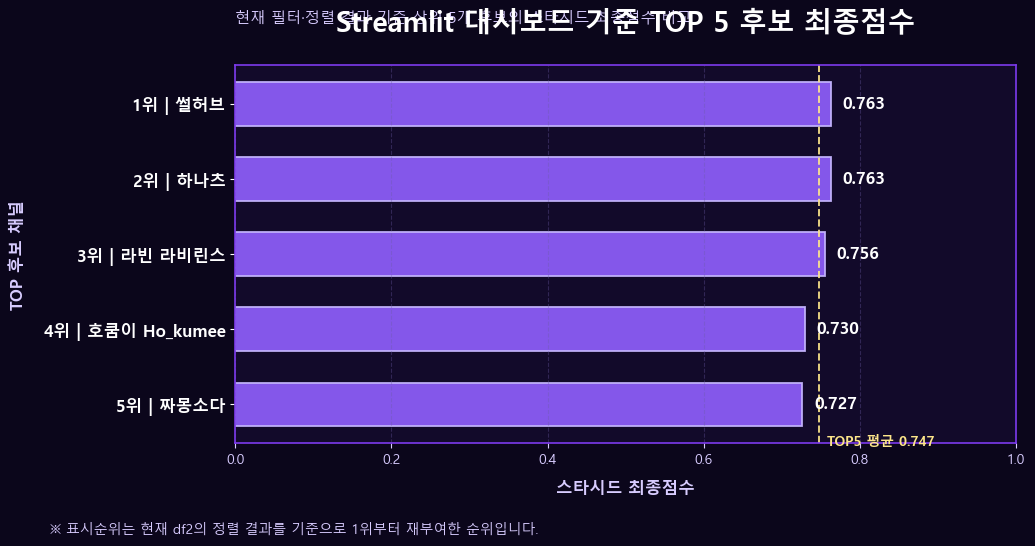

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import platform

# ============================================================
# TOP 5 후보 최종점수 막대그래프 - 표시순위 재매핑 버전
# df2는 이미 Streamlit 기준으로 정렬되어 있다고 가정
# ============================================================

# ------------------------------------------------------------
# 0. 한글 폰트 설정
# ------------------------------------------------------------
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":
    plt.rcParams["font.family"] = "AppleGothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 1. 데이터 준비
# ------------------------------------------------------------
df_plot = df2.copy()

df_plot["최종점수"] = pd.to_numeric(df_plot["최종점수"], errors="coerce")

# df2의 현재 정렬 순서를 그대로 유지한 채 표시순위 재부여
df_plot = df_plot.reset_index(drop=True)
df_plot["표시순위"] = df_plot.index + 1

# 현재 화면 기준 TOP 5 추출
top5 = (
    df_plot
    .dropna(subset=["최종점수"])
    .head(5)
    .copy()
)

top5["표시채널명"] = (
    top5["표시순위"].astype(int).astype(str)
    + "위 | "
    + top5["채널명"].astype(str)
)

# barh에서 1위가 위로 오게 뒤집기
top5_plot = top5.iloc[::-1].copy()

# ------------------------------------------------------------
# 2. 컬러 팔레트
# ------------------------------------------------------------
bg_color = "#0B061B"
panel_color = "#120A2A"
bar_color = "#8B5CF6"
bar_edge = "#C4B5FD"
text_color = "#FFFFFF"
sub_text = "#D8CCFF"
grid_color = "#6D5BA6"

# ------------------------------------------------------------
# 3. 그래프 생성
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 6), facecolor=bg_color)
ax.set_facecolor(panel_color)

y_pos = np.arange(len(top5_plot))

bars = ax.barh(
    y_pos,
    top5_plot["최종점수"],
    height=0.58,
    color=bar_color,
    edgecolor=bar_edge,
    linewidth=1.3,
    alpha=0.95
)

# ------------------------------------------------------------
# 4. 점수 라벨 표시
# ------------------------------------------------------------
for bar, score in zip(bars, top5_plot["최종점수"]):
    width = bar.get_width()

    ax.text(
        width + 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center",
        ha="left",
        fontsize=12,
        fontweight="bold",
        color=text_color
    )

# ------------------------------------------------------------
# 5. y축 라벨 설정
# ------------------------------------------------------------
ax.set_yticks(y_pos)
ax.set_yticklabels(
    top5_plot["표시채널명"],
    fontsize=12,
    color=text_color,
    fontweight="bold"
)

# ------------------------------------------------------------
# 6. x축 범위 및 스타일
# ------------------------------------------------------------
x_max = max(1.0, top5_plot["최종점수"].max() + 0.12)
ax.set_xlim(0, x_max)

ax.set_xlabel(
    "스타시드 최종점수",
    fontsize=12,
    color=sub_text,
    labelpad=10,
    fontweight="bold"
)

ax.set_ylabel(
    "TOP 후보 채널",
    fontsize=12,
    color=sub_text,
    labelpad=12,
    fontweight="bold"
)

ax.tick_params(axis="x", colors=sub_text, labelsize=10)
ax.tick_params(axis="y", colors=text_color)

# ------------------------------------------------------------
# 7. 제목 및 부제목
# ------------------------------------------------------------
ax.set_title(
    "Streamlit 대시보드 기준 TOP 5 후보 최종점수",
    fontsize=20,
    color=text_color,
    fontweight="bold",
    pad=24
)

ax.text(
    0,
    len(top5_plot) + 0.15,
    "현재 필터·정렬 결과 기준 상위 5개 후보의 스타시드 최종점수 비교",
    fontsize=11,
    color=sub_text,
    ha="left",
    va="center"
)

# ------------------------------------------------------------
# 8. 그리드 및 테두리 스타일
# ------------------------------------------------------------
ax.grid(
    axis="x",
    linestyle="--",
    linewidth=0.8,
    alpha=0.35,
    color=grid_color
)

for spine in ax.spines.values():
    spine.set_color("#7C3AED")
    spine.set_linewidth(1.2)

# ------------------------------------------------------------
# 9. TOP5 평균 기준선
# ------------------------------------------------------------
mean_score = top5_plot["최종점수"].mean()

ax.axvline(
    mean_score,
    color="#FDE68A",
    linestyle="--",
    linewidth=1.4,
    alpha=0.9
)

ax.text(
    mean_score + 0.01,
    -0.55,
    f"TOP5 평균 {mean_score:.3f}",
    color="#FDE68A",
    fontsize=10,
    fontweight="bold"
)

# ------------------------------------------------------------
# 10. 하단 주석
# ------------------------------------------------------------
fig.text(
    0.08,
    0.035,
    "※ 표시순위는 현재 df2의 정렬 결과를 기준으로 1위부터 재부여한 순위입니다.",
    color=sub_text,
    fontsize=10
)

plt.tight_layout(rect=[0.03, 0.07, 0.98, 0.95])

# ------------------------------------------------------------
# 11. PPT 삽입용 이미지 저장
# ------------------------------------------------------------
plt.savefig(
    "top5_starseed_final_score_ppt.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=fig.get_facecolor()
)

plt.show()